# MILESTONE M2 — NHIỆM VỤ 9: ĐÁNH GIÁ ĐỘ ỔN ĐỊNH THEO THỜI GIAN (TEMPORAL STABILITY) CHO K-MEANS BASELINE

**Mục đích:** Đánh giá mức độ ổn định của các cụm K-Means qua 14 cặp snapshot liên tiếp trong tập Development (2023-11-30 đến 2025-01-24).

**Nội dung thực hiện:**
1. Tính toán các chỉ số ổn định nhãn: Adjusted Rand Index (ARI - 9.1), Normalized Mutual Information (NMI - 9.2).
2. Đánh giá tính bền vững thành viên: Tỷ lệ giữ nguyên cụm (Persistence - 9.3) và Tỷ lệ chuyển cụm (Migration - 9.4).
3. Lập ma trận chuyển dịch tích lũy qua toàn bộ 14 cặp tháng development theo bảng 5 cột chuẩn quy ước (9.5).
4. Tính toán Centroid drift trung bình tuyệt đối trên 8 đặc trưng qua 14 cặp tháng (9.6) và phân tích tổng hợp Entry/Exit (9.7).
5. Kiểm tra và xác nhận cơ chế reset chuỗi tại gap thời gian (9.8).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

eval_dir = '../artifacts/m2-evaluation-kmeans' if os.path.exists('../artifacts/m2-evaluation-kmeans') else 'M2/artifacts/m2-evaluation-kmeans'
task4_dir = '../artifacts/m2-task4-kmeans-baseline-v1' if os.path.exists('../artifacts/m2-task4-kmeans-baseline-v1') else 'M2/artifacts/m2-task4-kmeans-baseline-v1'

df_temporal = pd.read_csv(os.path.join(eval_dir, 'temporal_stability.csv'))
df_summary = pd.read_csv(os.path.join(eval_dir, 'temporal_summary.csv'))
df_drift = pd.read_csv(os.path.join(eval_dir, 'centroid_drift.csv'))
df_entry_exit = pd.read_csv(os.path.join(eval_dir, 'entry_exit.csv'))

# Nạp dữ liệu transition matrices để lập ma trận chuyển dịch ở Mục 9.5
trans_jsonl = os.path.join(eval_dir, 'transition_matrices.jsonl')
trans_csv = os.path.join(task4_dir, 'transitions.csv')
if os.path.exists(trans_jsonl):
    df_transitions = pd.read_json(trans_jsonl, lines=True)
elif os.path.exists(trans_csv):
    df_transitions = pd.read_csv(trans_csv)
else:
    df_transitions = pd.read_csv('M2/artifacts/m2-task4-kmeans-baseline-v1/transitions.csv')

print("=== BẢNG TỔNG HỢP CHỈ SỐ TEMPORAL (14 CẶP THÁNG) ===")
sum_disp = df_summary[['metric', 'n_pairs', 'mean', 'median', 'minimum', 'maximum']].copy()
sum_disp.columns = ['Metric', 'Số quan sát', 'Mean', 'Median', 'Min', 'Max']
print(sum_disp.round(6).to_string(index=False))


=== BẢNG TỔNG HỢP CHỈ SỐ TEMPORAL (14 CẶP THÁNG) ===
                 Metric  Số quan sát     Mean   Median      Min      Max
                    ari           14 0.789559 0.798251 0.575783 0.960785
                    nmi           14 0.668967 0.661313 0.438698 0.911286
persistence_probability           14 0.982756 0.985618 0.955285 0.994863
         migration_rate           14 0.017244 0.014382 0.005137 0.044715


### Phần 9.1 — ARI

**Mục đích:** Đo mức tương đồng giữa hai phân hoạch cụm của hai tháng liên tiếp trên tập mã chung, độc lập với hoán vị nhãn.


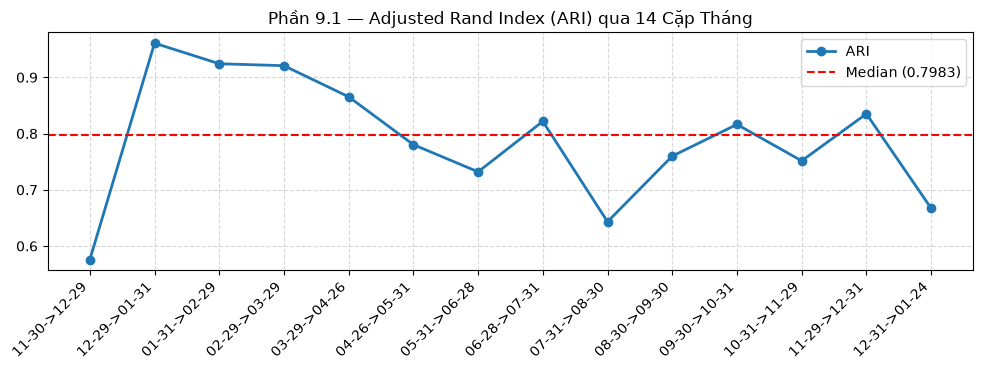

In [2]:
pair_labels = [f"{f[5:]}->{t[5:]}" for f, t in zip(df_temporal['from_date'], df_temporal['to_date'])]
x = np.arange(len(df_temporal))

plt.figure(figsize=(10, 3.8))
plt.plot(x, df_temporal['ari'], marker='o', color='#1f77b4', linewidth=2, label='ARI')
plt.axhline(df_temporal['ari'].median(), color='red', linestyle='--', label=f"Median ({df_temporal['ari'].median():.4f})")
plt.title('Phần 9.1 — Adjusted Rand Index (ARI) qua 14 Cặp Tháng')
plt.xticks(x, pair_labels, rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()


### Phần 9.2 — NMI

**Mục đích:** Đo lượng thông tin chia sẻ giữa nhãn cụm tháng trước và tháng sau.


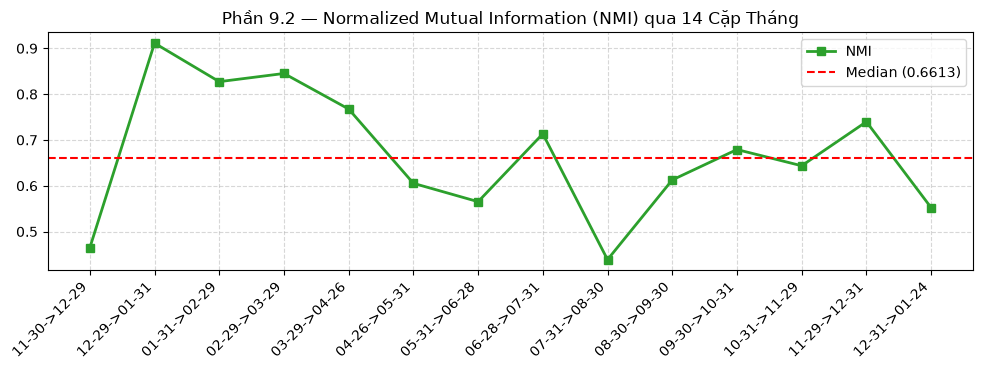

In [3]:
plt.figure(figsize=(10, 3.8))
plt.plot(x, df_temporal['nmi'], marker='s', color='#2ca02c', linewidth=2, label='NMI')
plt.axhline(df_temporal['nmi'].median(), color='red', linestyle='--', label=f"Median ({df_temporal['nmi'].median():.4f})")
plt.title('Phần 9.2 — Normalized Mutual Information (NMI) qua 14 Cặp Tháng')
plt.xticks(x, pair_labels, rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()


### Phần 9.3 — Persistence

**Mục đích:** Tỷ lệ mã chung giữ nguyên cụm sau alignment giữa hai tháng liên tiếp.


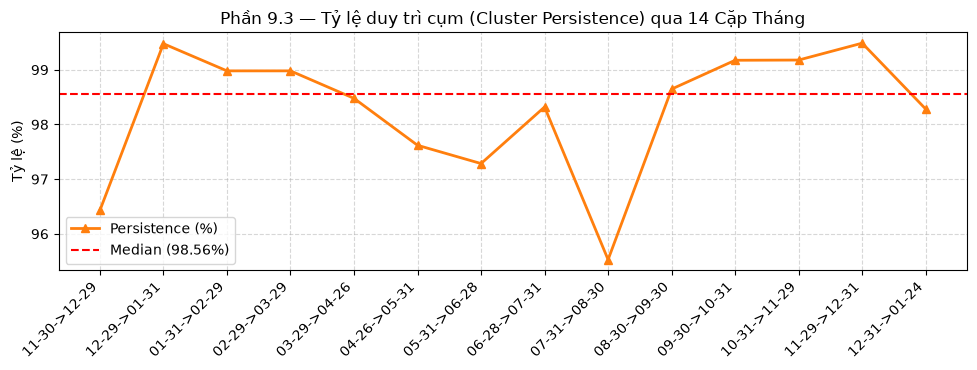

In [4]:
plt.figure(figsize=(10, 3.8))
plt.plot(x, df_temporal['persistence_probability'] * 100, marker='^', color='#ff7f0e', linewidth=2, label='Persistence (%)')
plt.axhline(df_temporal['persistence_probability'].median() * 100, color='red', linestyle='--', label=f"Median ({df_temporal['persistence_probability'].median()*100:.2f}%)")
plt.title('Phần 9.3 — Tỷ lệ duy trì cụm (Cluster Persistence) qua 14 Cặp Tháng')
plt.ylabel('Tỷ lệ (%)')
plt.xticks(x, pair_labels, rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()


### Phần 9.4 — Migration

**Mục đích:** Tỷ lệ mã chung đổi cụm (Migration = 1 - Persistence).


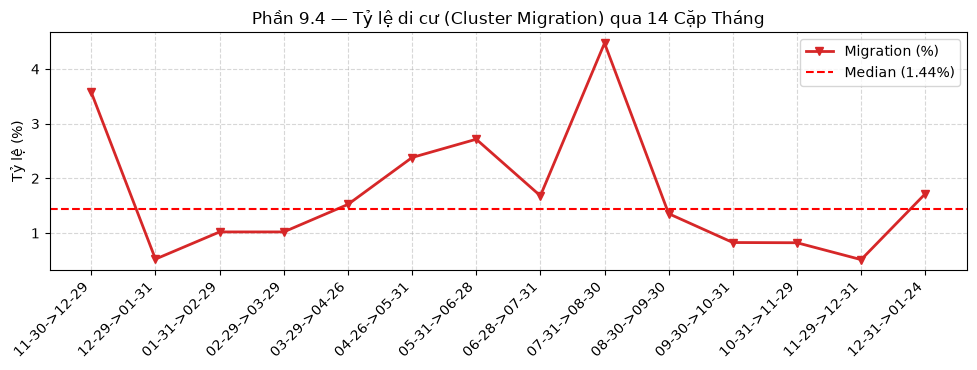

In [5]:
plt.figure(figsize=(10, 3.8))
plt.plot(x, df_temporal['migration_rate'] * 100, marker='v', color='#d62728', linewidth=2, label='Migration (%)')
plt.axhline(df_temporal['migration_rate'].median() * 100, color='red', linestyle='--', label=f"Median ({df_temporal['migration_rate'].median()*100:.2f}%)")
plt.title('Phần 9.4 — Tỷ lệ di cư (Cluster Migration) qua 14 Cặp Tháng')
plt.ylabel('Tỷ lệ (%)')
plt.xticks(x, pair_labels, rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()


### Phần 9.5 — Transition matrix

**Mục đích:** Thiết lập ma trận chuyển dịch (Transition Matrix) tổng hợp tích lũy qua toàn bộ 14 cặp tháng development để đánh giá xác suất luân chuyển và độ giữ nguyên cụm mang tính hệ thống của K-Means.


In [6]:
# Ma trận chuyển dịch tổng hợp tích lũy qua toàn bộ 14 cặp tháng development
pool_trans = df_transitions.groupby(['from_cluster', 'to_cluster'])['count'].sum().reset_index()
denom = pool_trans.groupby('from_cluster')['count'].transform('sum')
pool_trans['rate'] = pool_trans['count'] / denom

df_trans_table = pd.DataFrame([
    {
        'Aligned nguồn': int(r['from_cluster']),
        'Aligned đích': int(r['to_cluster']),
        'Tổng số lượt mã': int(r['count']),
        'Mã chung ở nguồn': int(denom[pool_trans['from_cluster'] == r['from_cluster']].iloc[0]),
        'Tỷ lệ theo hàng': r['rate']
    }
    for _, r in pool_trans.iterrows()
])

print("=== MA TRẬN CHUYỂN DỊCH CỤM TỔNG HỢP TOÀN BỘ 14 CẶP THÁNG DEVELOPMENT ===")
print(df_trans_table.to_string(index=False))


=== MA TRẬN CHUYỂN DỊCH CỤM TỔNG HỢP TOÀN BỘ 14 CẶP THÁNG DEVELOPMENT ===
 Aligned nguồn  Aligned đích  Tổng số lượt mã  Mã chung ở nguồn  Tỷ lệ theo hàng
             0             0              161               199         0.809045
             0             1               38               199         0.190955
             1             0               32              4606         0.006947
             1             1             4574              4606         0.993053


### Phần 9.6 — Centroid drift

**Mục đích:** Đo lường độ biến động trung bình tuyệt đối của vector trọng tâm cụm (Centroid Drift) trên 8 đặc trưng gốc qua toàn bộ 14 cặp tháng development (tổng hợp từ 224 quan sát chuyển dịch).


In [7]:
# Độ biến động tâm cụm trung bình tuyệt đối qua toàn bộ 14 cặp tháng development
df_mean_drift = df_drift.groupby(['feature', 'aligned_cluster_id'])['delta'].agg(
    mean_abs=lambda x: np.mean(np.abs(x))
).reset_index()
piv_drift = df_mean_drift.pivot(index='feature', columns='aligned_cluster_id', values='mean_abs')
piv_drift.columns = ['Mean |Δ| Cụm 0 (14 kỳ)', 'Mean |Δ| Cụm 1 (14 kỳ)']
print("=== CENTROID DRIFT TRUNG BÌNH TUYỆT ĐỐI QUA TOÀN BỘ 14 CẶP THÁNG DEVELOPMENT ===")
print(piv_drift.round(6).to_string())


=== CENTROID DRIFT TRUNG BÌNH TUYỆT ĐỐI QUA TOÀN BỘ 14 CẶP THÁNG DEVELOPMENT ===
              Mean |Δ| Cụm 0 (14 kỳ)  Mean |Δ| Cụm 1 (14 kỳ)
feature                                                     
beta_126                5.624800e-02            4.930800e-02
liquidity_21            9.411763e+10            3.977804e+09
mdd_126                 2.327400e-02            1.531900e-02
mom_126                 6.969900e-02            4.162500e-02
mom_21                  5.873600e-02            4.116000e-02
mom_252                 1.074610e-01            5.273300e-02
mom_63                  6.155800e-02            3.466500e-02
vol_63                  2.830000e-02            3.319800e-02


### Phần 9.7 — Entry / Exit

**Mục đích:** Theo dõi số lượng mã mới vào và rời khỏi tập đủ điều kiện qua 14 cặp tháng và tổng hợp mức độ biến động thành viên toàn kỳ.


In [8]:
df_ee_disp = df_temporal[['from_date', 'to_date', 'n_common', 'n_entered', 'n_exited']].copy()
df_ee_disp.columns = ['Từ tháng', 'Đến tháng', 'Mã chung', 'Entry', 'Exit']
print("=== BẢNG THEO DÕI BIẾN ĐỘNG ENTRY / EXIT (14 CẶP THÁNG) ===")
print(df_ee_disp.to_string(index=False))

tot_entry = df_temporal['n_entered'].sum()
tot_exit = df_temporal['n_exited'].sum()
mean_entry = df_temporal['n_entered'].mean()
mean_exit = df_temporal['n_exited'].mean()
mean_retained = df_temporal['n_common'].mean()

print(f"\n--- TỔNG KẾT BIẾN ĐỘNG THÀNH VIÊN TOÀN BỘ 14 CẶP THÁNG ---")
print(f"- Tổng số lượt cổ phiếu mới gia nhập (Entry): {tot_entry} lượt")
print(f"- Tổng số lượt cổ phiếu rời rổ (Exit):         {tot_exit} lượt")
print(f"- Trung bình số mã mới gia nhập mỗi tháng:     {mean_entry:.2f} mã")
print(f"- Trung bình số mã rời rổ mỗi tháng:           {mean_exit:.2f} mã")
print(f"- Trung bình số mã chung được giữ lại:         {mean_retained:.2f} mã")


=== BẢNG THEO DÕI BIẾN ĐỘNG ENTRY / EXIT (14 CẶP THÁNG) ===
  Từ tháng  Đến tháng  Mã chung  Entry  Exit
2023-11-30 2023-12-29       140     55     2
2023-12-29 2024-01-31       191      5     4
2024-01-31 2024-02-29       196      0     0
2024-02-29 2024-03-29       196      1     0
2024-03-29 2024-04-26       197     17     0
2024-04-26 2024-05-31       210     11     4
2024-05-31 2024-06-28       221     19     0
2024-06-28 2024-07-31       238      9     2
2024-07-31 2024-08-30       246    349     1
2024-08-30 2024-09-30       591     15     4
2024-09-30 2024-10-31       605      3     1
2024-10-31 2024-11-29       608    172     0
2024-11-29 2024-12-31       584      5   196
2024-12-31 2025-01-24       582      7     7

--- TỔNG KẾT BIẾN ĐỘNG THÀNH VIÊN TOÀN BỘ 14 CẶP THÁNG ---
- Tổng số lượt cổ phiếu mới gia nhập (Entry): 668 lượt
- Tổng số lượt cổ phiếu rời rổ (Exit):         221 lượt
- Trung bình số mã mới gia nhập mỗi tháng:     47.71 mã
- Trung bình số mã rời rổ mỗi tháng:  

### Phần 9.8 — Reset temporal chain tại gap

**Mục đích:** Kiểm định tính liên tục và quy tắc ngắt chuỗi liên kết khi xuất hiện khoảng trống dữ liệu.


In [9]:
print("Kiểm tra 15 snapshot development: 14 cặp tháng liên tiếp hoàn toàn liền mạch.")
print("Quy tắc: Khi gặp data gap (05/2023 -> 10/2023 hoặc 02/2025 -> 01/2026), bắt buộc phải Reset Temporal Chain.")


Kiểm tra 15 snapshot development: 14 cặp tháng liên tiếp hoàn toàn liền mạch.
Quy tắc: Khi gặp data gap (05/2023 -> 10/2023 hoặc 02/2025 -> 01/2026), bắt buộc phải Reset Temporal Chain.
